In [8]:
import pandas as pd
from ortools.linear_solver import pywraplp
import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
EXPORT_PATH = '2026-04-22_17-04-38' 

try:
    employees_df = pd.read_csv(f'{EXPORT_PATH}/employees.csv')
    tasks_df = pd.read_csv(f'{EXPORT_PATH}/tasks.csv')
except FileNotFoundError:
    print("Error: Could not find the CSVs.")
    raise

def parse_skill_string(skill_str):
    if pd.isna(skill_str) or not isinstance(skill_str, str):
        return {}
    skill_dict = {}
    for item in skill_str.split('|'):
        if ':' in item:
            skill, level = item.split(':')
            skill_dict[skill.strip()] = int(level.strip())
    return skill_dict

display(employees_df.head())
display(tasks_df.head())

,Employee_ID,Profile_Level,Primary_Category,Specific_Skills,Hourly_Cost,Max_Hours
0,E001,1,Backend,Java:1|C#:2|TypeScript:1,77,2080
1,E002,2,Backend,C#:1|Python:3|Go:3,107,2080
2,E003,2,Frontend,React:3|TypeScript:2|Selenium:1,94,2080
3,E004,2,Backend,Go:1|C#:3,78,2080
4,E005,1,DevOps,Kubernetes:1|Terraform:2|Vue.js:1,80,2080


,Project_ID,Task_ID,Category,Skills_Needed,Complexity_Level,Hours_Needed
0,P001,P001_T1,Testing,JUnit:2,2,80
1,P001,P001_T2,DevOps,AWS:2|Kubernetes:2,2,240
2,P002,P002_T1,DevOps,AWS:4,4,160
3,P002,P002_T2,DevOps,AWS:1,1,100
4,P002,P002_T3,Frontend,Vue.js:1|TypeScript:1,1,120


In [128]:
employees_df['Specific_Skills_Dict'] = employees_df['Specific_Skills'].apply(parse_skill_string)
tasks_df['Req_Dict'] = tasks_df['Skills_Needed'].apply(parse_skill_string)

if 'EXT_CONTRACTOR' not in employees_df['Employee_ID'].values:
    all_required_skills = set()
    for req_dict in tasks_df['Req_Dict']:
        all_required_skills.update(req_dict.keys())

    contractor_skills = {skill: 5 for skill in all_required_skills}

    contractor = pd.DataFrame([{
        'Employee_ID': 'EXT_CONTRACTOR',
        'Specific_Skills_Dict': contractor_skills,
        'Hourly_Cost': 5000,
        'Max_Hours': 999999
    }])
    employees_df = pd.concat([employees_df, contractor], ignore_index=True) 

In [129]:
def calculate_skill_rho(emp_level, task_level):
    if emp_level == 0:
        return 0.2  # MISSING SKILL PENALTY: Takes 5x as long
    elif emp_level == task_level:
        return 1.0  # Perfect match
    elif emp_level > task_level:
        return 1.5  # Over-qualified
    else:
        return 0.5  # Under-qualified

valid_pairs = []
rho_dict = {} 

for _, emp in employees_df.iterrows():
    emp_skills = emp['Specific_Skills_Dict']
    
    for _, task in tasks_df.iterrows():
        task_reqs = task['Req_Dict']
        
        skill_rhos = []
        missing_skills_count = 0
        
        # Loop through all requirements. No 'issubset' strict check here.
        for skill, req_level in task_reqs.items():
            # If they don't have the skill, it defaults to Level 0
            emp_level = emp_skills.get(skill, 0)
            
            if emp_level == 0:
                missing_skills_count += 1
                
            skill_rhos.append(calculate_skill_rho(emp_level, req_level))
        
        # LOGICAL RULE: Employee must possess AT LEAST ONE of the required skills.
        # This prevents the solver from assigning someone who is 100% unqualified.
        if missing_skills_count < len(task_reqs):
            
            # Apply the Bottleneck Principle
            overall_rho = min(skill_rhos)
            
            pair = (emp['Employee_ID'], task['Task_ID'])
            valid_pairs.append(pair)
            rho_dict[pair] = overall_rho

print(f"Generated {len(valid_pairs)} valid assignment pairs (Including Soft Penalty Matches).")


Generated 131 valid assignment pairs (Including Soft Penalty Matches).


In [130]:
solver = pywraplp.Solver.CreateSolver('SCIP')

# A. Decision Variables (Integer)
x = {}
for (i, j) in valid_pairs:
    x[(i, j)] = solver.IntVar(0, solver.infinity(), f'x_{i}_{j}')

# B. Objective Function (Minimize Cost)
cost_dict = employees_df.set_index('Employee_ID')['Hourly_Cost'].to_dict()
objective = solver.Objective()
for (i, j) in valid_pairs:
    objective.SetCoefficient(x[(i, j)], float(cost_dict[i]))
objective.SetMinimization()

# C. Constraint 1: Demand Satisfaction (With Bottleneck Rho)
demand_dict = tasks_df.set_index('Task_ID')['Hours_Needed'].to_dict()
for j in tasks_df['Task_ID']:
    capable_employees = [i for (i, t_id) in valid_pairs if t_id == j]
    constraint = solver.Constraint(float(demand_dict[j]), solver.infinity(), f"Demand_{j}")
    for i in capable_employees:
        rho = rho_dict[(i, j)]
        constraint.SetCoefficient(x[(i, j)], float(rho))

# D. Constraint 2: Integer Capacity Limit
cap_dict = employees_df.set_index('Employee_ID')['Max_Hours'].to_dict()
for i in employees_df['Employee_ID']:
    assigned_tasks = [j for (e_id, j) in valid_pairs if e_id == i]
    constraint = solver.Constraint(0, float(cap_dict[i]), f"Capacity_{i}")
    for j in assigned_tasks:
        constraint.SetCoefficient(x[(i, j)], 1)


In [131]:
status = solver.Solve()

if status == pywraplp.Solver.OPTIMAL:
    print(f"\n✅ Status: OPTIMAL (MILP Solution)")
    print(f"💰 Total Optimized Cost: ${solver.Objective().Value():,.2f}")
    
    results = []
    for (i, j) in valid_pairs:
        assigned_clock_hours = x[(i, j)].solution_value()
        if assigned_clock_hours > 0: 
            rho = rho_dict[(i, j)]
            results.append({
                'Task_ID': j,
                'Employee_ID': i,
                'Bottleneck_Rho': rho,
                'Clock_Hours': assigned_clock_hours,
                'Effective_Progress': assigned_clock_hours * rho,
                'Cost': assigned_clock_hours * cost_dict[i]
            })
            
    results_df = pd.DataFrame(results).sort_values(by=['Task_ID', 'Employee_ID']).reset_index(drop=True)
    
    display_df = results_df.merge(tasks_df[['Task_ID', 'Hours_Needed', 'Req_Dict']], on='Task_ID')
    display_df = display_df.merge(employees_df[['Employee_ID', 'Specific_Skills_Dict']], on='Employee_ID')
    
    print("\n--- Snippet of Optimal Assignment Schedule ---")
    display(display_df[['Task_ID', 'Employee_ID', 'Bottleneck_Rho', 'Hours_Needed', 'Clock_Hours', 'Cost', 'Req_Dict', 'Specific_Skills_Dict']])
    
    # Contractor check
    contractor_hrs = results_df[results_df['Employee_ID'] == 'EXT_CONTRACTOR']['Clock_Hours'].sum()
    if contractor_hrs > 0:
        print(f"\n🚨 ALERT: Outsourced {contractor_hrs:,.0f} hours to EXT_CONTRACTOR due to skill shortages.")
else:
    print("Solver failed. Status:", status)


✅ Status: OPTIMAL (MILP Solution)
💰 Total Optimized Cost: $761,109.00

--- Snippet of Optimal Assignment Schedule ---


,Task_ID,Employee_ID,Bottleneck_Rho,Hours_Needed,Clock_Hours,Cost,Req_Dict,Specific_Skills_Dict
0,P001_T1,E013,1.0,80,80.0,5840.0,{'JUnit': 2},"{'Selenium': 1, 'JUnit': 2}"
1,P001_T2,E005,0.2,240,1200.0,96000.0,"{'AWS': 2, 'Kubernetes': 2}","{'Kubernetes': 1, 'Terraform': 2, 'Vue.js': 1}"
2,P002_T1,E025,0.5,160,320.0,26240.0,{'AWS': 4},"{'Docker': 2, 'AWS': 2}"
3,P002_T2,E025,1.5,100,67.0,5494.0,{'AWS': 1},"{'Docker': 2, 'AWS': 2}"
4,P002_T3,E007,1.5,120,80.0,6800.0,"{'Vue.js': 1, 'TypeScript': 1}","{'Vue.js': 2, 'TypeScript': 2, 'AWS': 1}"
5,P003_T1,E023,1.0,40,40.0,2680.0,{'Angular': 1},"{'Angular': 1, 'TypeScript': 1}"
6,P003_T2,E014,1.5,120,80.0,15840.0,{'SQL': 1},"{'SQL': 5, 'Spark': 5, 'Pandas': 5, 'Selenium'..."
7,P004_T1,E013,0.2,80,400.0,29200.0,"{'JUnit': 1, 'PyTest': 1}","{'Selenium': 1, 'JUnit': 2}"
8,P004_T2,E006,1.0,240,240.0,22320.0,"{'Go': 2, 'Java': 1}","{'Go': 2, 'Java': 2, 'AWS': 1}"
9,P004_T3,E004,0.2,300,1500.0,117000.0,"{'Node.js': 3, 'Go': 1}","{'Go': 1, 'C#': 3}"



--- Employee Utilization ---
Employee E013: Used 560.00 hours out of 2080 hours (26.9% utilized)
Employee E005: Used 1280.00 hours out of 2080 hours (61.5% utilized)
Employee E025: Used 427.00 hours out of 2080 hours (20.5% utilized)
Employee E007: Used 160.00 hours out of 2080 hours (7.7% utilized)
Employee E023: Used 40.00 hours out of 2080 hours (1.9% utilized)
Employee E014: Used 120.00 hours out of 2080 hours (5.8% utilized)
Employee E006: Used 280.00 hours out of 2080 hours (13.5% utilized)
Employee E004: Used 1500.00 hours out of 2080 hours (72.1% utilized)
Employee E001: Used 2080.00 hours out of 2080 hours (100.0% utilized)
Employee E022: Used 1320.00 hours out of 2080 hours (63.5% utilized)
Employee E011: Used 160.00 hours out of 2080 hours (7.7% utilized)
Employee E024: Used 40.00 hours out of 2080 hours (1.9% utilized)
Employee E017: Used 80.00 hours out of 2080 hours (3.8% utilized)
Employee E003: Used 53.00 hours out of 2080 hours (2.5% utilized)
Employee E018: Used 1.00

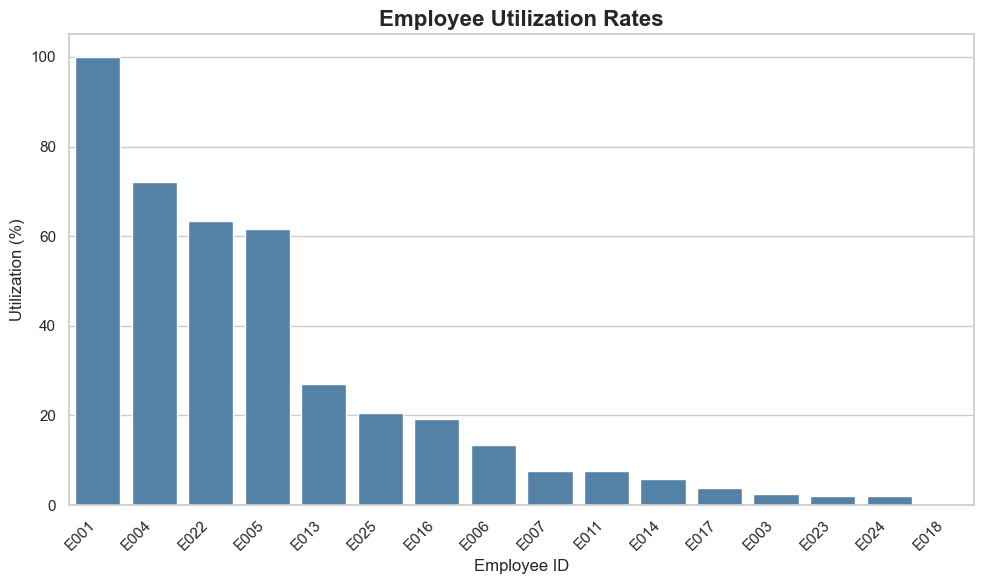

In [132]:
time_used_dict = employees_df.set_index('Employee_ID')['Max_Hours'].to_dict()
results_df['Time_Used'] = results_df.apply(lambda row: time_used_dict[row['Employee_ID']], axis=1)
utilization_dict = results_df.groupby('Employee_ID')['Clock_Hours'].sum().to_dict()
print("\n--- Employee Utilization ---")
for emp_id in results_df['Employee_ID'].unique():
    emp_time_used = results_df[results_df['Employee_ID'] == emp_id]['Clock_Hours'].sum()
    emp_time_available = time_used_dict[emp_id]
    utilization = (emp_time_used / emp_time_available) * 100 if emp_time_available > 0 else 0
    utilization_dict[emp_id] = utilization
    print(f"Employee {emp_id}: Used {emp_time_used:.2f} hours out of {emp_time_available} hours ({utilization:.1f}% utilized)")

utilization_data = pd.DataFrame(list(utilization_dict.items()), columns=['Employee_ID', 'Utilization'])
utilization_data = utilization_data.sort_values(by='Utilization', ascending=False).reset_index(drop=True)
plt.figure(figsize=(10, 6))
sns.barplot(data=utilization_data, x='Employee_ID', y='Utilization', color='steelblue')
plt.title('Employee Utilization Rates', fontsize=16, fontweight='bold')
plt.xlabel('Employee ID', fontsize=12)
plt.ylabel('Utilization (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [133]:
not_assigned_employees = set(employees_df['Employee_ID']) - set(results_df['Employee_ID'])
print(f"Total Unassigned Employees: {len(not_assigned_employees)}")

Total Unassigned Employees: 10



📊 Saved Chart 1 (False Economy) to: 2026-04-22_17-04-38/false_economy_chart.png


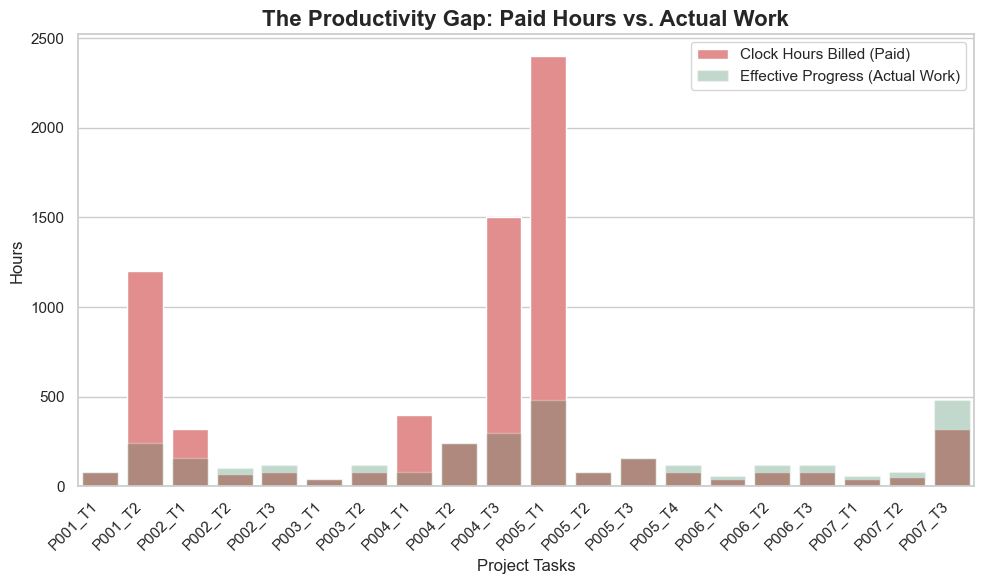

📊 Saved Chart 2 (Cost Distribution) to: 2026-04-22_17-04-38/cost_distribution_chart.png


/var/folders/rv/jrnyg0dj6610p3b7wcp05hg40000gn/T/ipykernel_49209/244924889.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=cost_summary[:15], x='Employee_ID', y='Cost', palette='viridis')


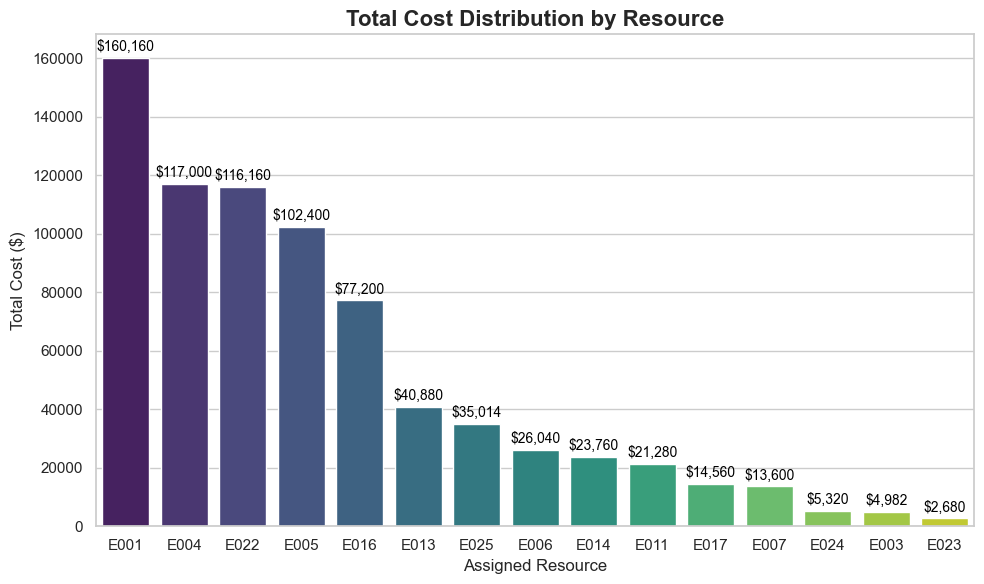

In [134]:
sns.set_theme(style="whitegrid")

task_summary = display_df.groupby('Task_ID')[['Clock_Hours', 'Effective_Progress']].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=task_summary[:20], x='Task_ID', y='Clock_Hours', color='lightcoral', label='Clock Hours Billed (Paid)')
sns.barplot(data=task_summary[:20], x='Task_ID', y='Effective_Progress', color='seagreen', label='Effective Progress (Actual Work)', alpha = 0.3)

plt.title('The Productivity Gap: Paid Hours vs. Actual Work', fontsize=16, fontweight='bold')
plt.xlabel('Project Tasks', fontsize=12)
plt.ylabel('Hours', fontsize=12)
plt.legend(loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

chart1_path = f"{EXPORT_PATH}/false_economy_chart.png"
plt.savefig(chart1_path, dpi=300)
print(f"\n📊 Saved Chart 1 (False Economy) to: {chart1_path}")
plt.show()

cost_summary = display_df.groupby('Employee_ID')['Cost'].sum().reset_index()
cost_summary = cost_summary.sort_values('Cost', ascending=False)

plt.figure(figsize=(10, 6))
bars = sns.barplot(data=cost_summary[:15], x='Employee_ID', y='Cost', palette='viridis')

for i, bar in enumerate(bars.patches):
    if cost_summary.iloc[i]['Employee_ID'] == 'EXT_CONTRACTOR':
        bar.set_color('firebrick')

plt.title('Total Cost Distribution by Resource', fontsize=16, fontweight='bold')
plt.xlabel('Assigned Resource', fontsize=12)
plt.ylabel('Total Cost ($)', fontsize=12)

for p in bars.patches:
    bars.annotate(f'${p.get_height():,.0f}', 
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                  ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5), 
                  textcoords='offset points')

plt.tight_layout()

chart2_path = f"{EXPORT_PATH}/cost_distribution_chart.png"
plt.savefig(chart2_path, dpi=300)
print(f"📊 Saved Chart 2 (Cost Distribution) to: {chart2_path}")
plt.show()